In [31]:
import pandas as pd
import numpy as np
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter


In [32]:
hazard_table = pd.read_csv('/Users/daniellancet/Desktop/Spring_2026/CDSS_170/CANS_INCIDENTS_PROJECT/Novel_Data/final_hazard_table.csv')

# Incident Types



- Abuse/CPS Report
- Suicide Related Incidents
- Behavioral_Incidents
- AWOL/ Child_Absense
- Health/Medical_Incidents
- Police_Involvement

In [33]:
incident_types = ['Abuse/CPS Report', 'Suicide Related Incidents', 'Behavioral_Incidents',  'AWOL/ Child_Absense',  'Health/Medical_Incidents', 'Police_Involvement']
just_first_assessement = hazard_table[hazard_table['DateCompleted'] == hazard_table['origin_assessment']] 

In [34]:
INCIDENT_TYPE = 'Abuse/CPS Report'
just_first_assessement['OptionsNumber']
col = 'first_incident_date_Suicide Related Incidents'
left_censor = just_first_assessement[just_first_assessement[col] < just_first_assessement['origin_assessment']]
exclude_optionsNumber = left_censor['OptionsNumber'].unique() 
just_first_assessement = just_first_assessement[~just_first_assessement['OptionsNumber'].isin(exclude_optionsNumber)]

In [35]:
cans = list(hazard_table.filter(like = 'alt_').columns)
covariates = list(hazard_table.filter(like = 'alt_').columns) #+ ['AgeWhenAssessed', 'Black', 'Latino', 'Asian', 'Other', 'Native']

def modeling_function(just_first_assessement, incident_type, covariates = covariates): 
    # handle left censor 
    col = 'first_incident_date_' + incident_type
    left_censor = just_first_assessement[just_first_assessement[col] < just_first_assessement['origin_assessment']]
    
    exclude_optionsNumber = left_censor['OptionsNumber'].unique() 
    just_first_assessement = just_first_assessement[~just_first_assessement['OptionsNumber'].isin(exclude_optionsNumber)]
    dur = 'T_' + incident_type
    event_col = 'status_'+ incident_type
    cox_table = just_first_assessement[[dur, event_col] + covariates]
    cph = CoxPHFitter()
    cph.fit(
        cox_table, 
        event_col = event_col,
        duration_col =  dur
    )

    return cph, cox_table, left_censor

for incident_type in incident_types: 
    cph, cox_table, left_censor = modeling_function(just_first_assessement, incident_type=incident_type)
    print(incident_type, left_censor.shape[0])



Abuse/CPS Report 65
Suicide Related Incidents 0
Behavioral_Incidents 27
AWOL/ Child_Absense 32
Health/Medical_Incidents 15
Police_Involvement 30


# Check Proportional Hazards Assumption


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


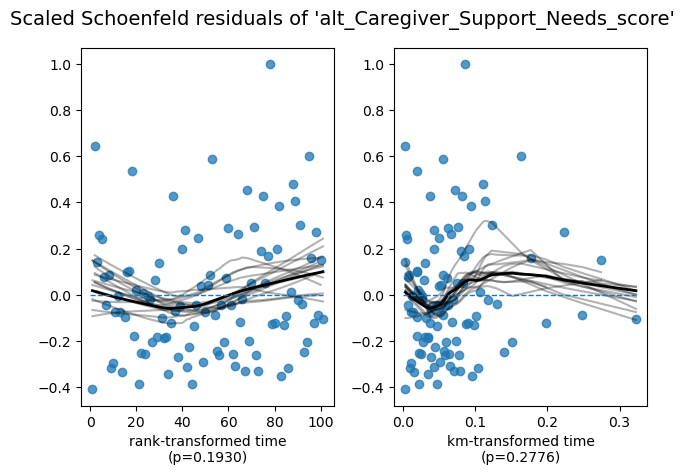

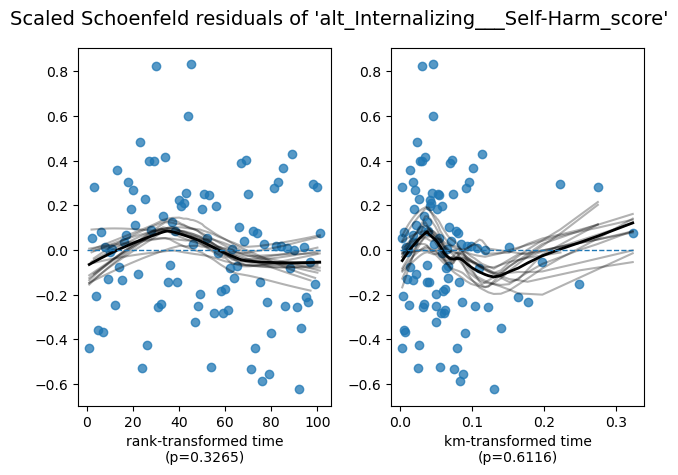

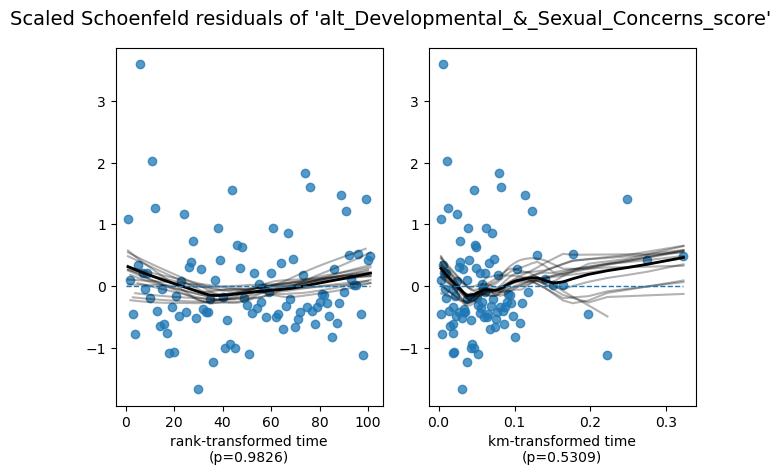

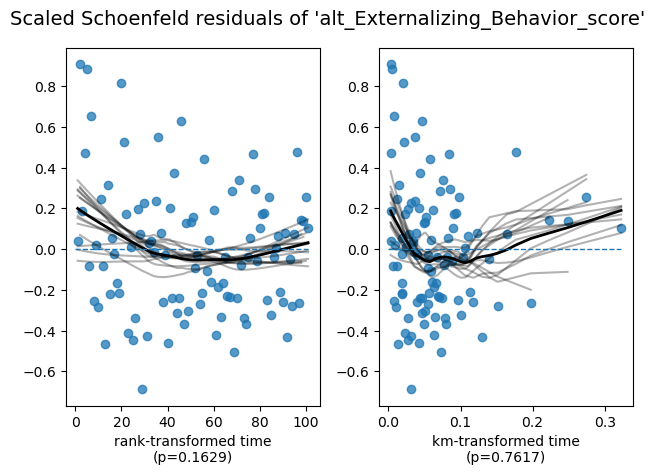

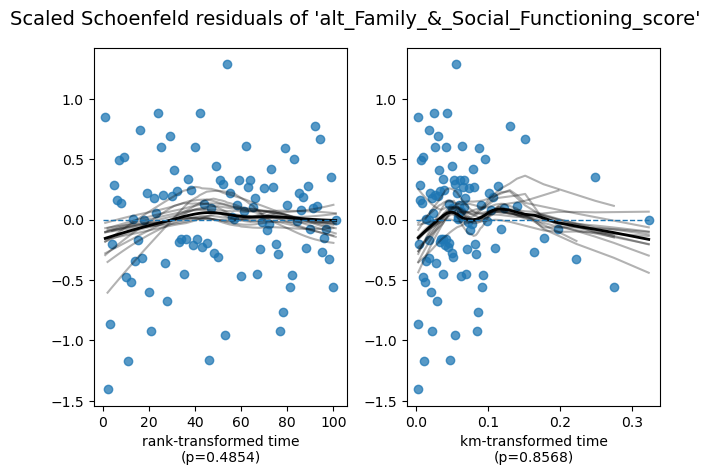

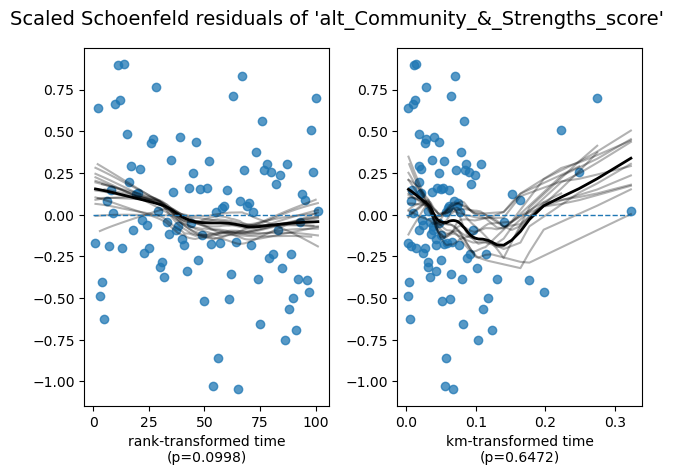

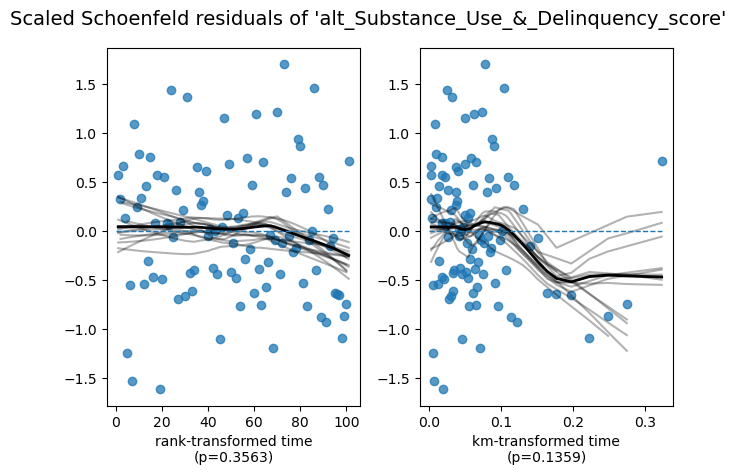

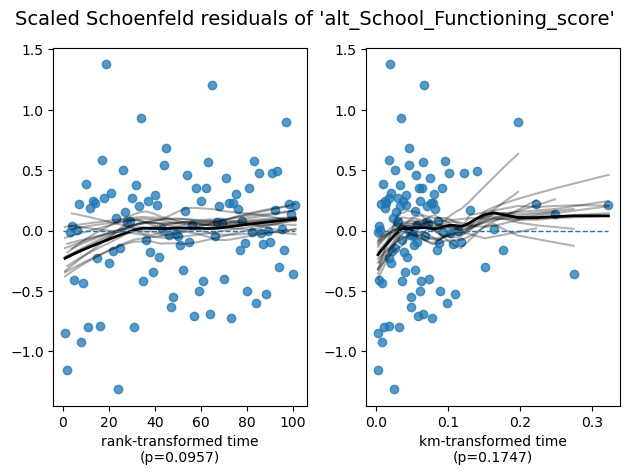

In [40]:
cph.check_assumptions(cox_table, show_plots=True);

# Model Summary

In [37]:
cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
alt_Caregiver_Support_Needs_score,-0.025525,0.974798,0.028394,-0.081178,0.030127,0.922030,1.030585,0.0,-0.898956,0.368676,1.439575
alt_Internalizing___Self-Harm_score,-0.009748,0.990300,0.031438,-0.071366,0.051870,0.931121,1.053239,0.0,-0.310060,0.756515,0.402559
alt_Developmental_&_Sexual_Concerns_score,-0.137675,0.871382,0.085336,-0.304931,0.029581,0.737174,1.030023,0.0,-1.613319,0.106675,3.228702
alt_Externalizing_Behavior_score,0.077204,1.080262,0.031827,0.014824,0.139583,1.014934,1.149795,0.0,2.425723,0.015278,6.032409
alt_Family_&_Social_Functioning_score,0.003008,1.003013,0.046371,-0.087877,0.093893,0.915874,1.098443,0.0,0.064876,0.948273,0.076626
alt_Community_&_Strengths_score,0.019220,1.019406,0.040194,-0.059559,0.097999,0.942180,1.102961,0.0,0.478182,0.632521,0.660815
alt_Substance_Use_&_Delinquency_score,0.205609,1.228272,0.066378,0.075511,0.335707,1.078435,1.398928,0.0,3.097553,0.001951,9.001380
alt_School_Functioning_score,0.024287,1.024585,0.041900,-0.057836,0.106410,0.943805,1.112278,0.0,0.579645,0.562154,0.830962


# Coefficient Plot

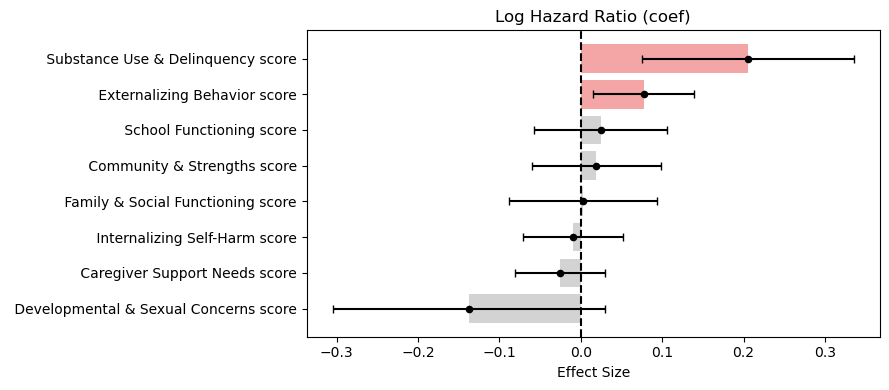

In [38]:
exclude = [var for var in  covariates if var not in cans]
def plot_cox_coefs(cph_model, exclude_vars=None, sort_by="coef", figsize_scale=0.5,
                   fade_nonsignificant=True, title=None):
    """Horizontal bar chart of log hazard ratios with 95% CI and center dots."""
    summary = cph_model.summary.copy()

    if exclude_vars:
        summary = summary.drop(index=[v for v in exclude_vars if v in summary.index])

    if sort_by == "abs_coef":
        summary = summary.reindex(summary["coef"].abs().sort_values().index)
    else:
        summary = summary.sort_values(by="coef")

    neg_color = "#a8ddb5"
    pos_color = "#f4a6a6"

    if fade_nonsignificant:
        colors = [
            neg_color if (coef < 0 and p < 0.05)
            else pos_color if (coef > 0 and p < 0.05)
            else "#d3d3d3"
            for coef, p in zip(summary["coef"], summary["p"])
        ]
    else:
        colors = [neg_color if coef < 0 else pos_color for coef in summary["coef"]]

    group_names = [name.replace('_', ' ').replace('alt', '').replace('  ', '') for name in summary.index.tolist()]

    fig, ax = plt.subplots(figsize=(9, figsize_scale * len(summary)))
    ax.barh(group_names, summary["coef"], color=colors, zorder=2)

    lower_err = summary["coef"] - summary["coef lower 95%"]
    upper_err = summary["coef upper 95%"] - summary["coef"]
    ax.errorbar(
        summary["coef"], group_names,
        xerr=[lower_err, upper_err],
        fmt='none', ecolor='black', capsize=3, zorder=3
    )
    ax.scatter(summary["coef"], group_names, color='black', zorder=4, s=20)
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(title or "Log Hazard Ratio (coef)")
    ax.set_xlabel("Effect Size")
    plt.tight_layout()
    plt.show()


plot_cox_coefs(cph, exclude_vars=exclude)

# Survival Curves by Values

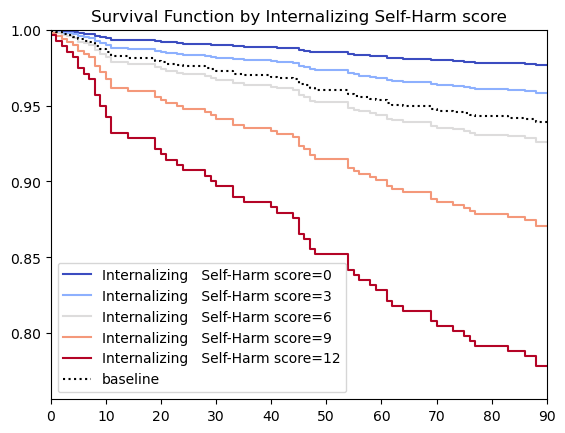

In [87]:
def plot_survival_curves(cph, cans, values=[0, 3, 6, 9, 12], xlim=(0, 90), p_threshold=0.05):
    summary = cph.summary.loc[cans]
    sig_vars = summary[summary['p'] < p_threshold]['coef'].abs().sort_values(ascending=False).index.tolist()

    for var in sig_vars:
        ax = cph.plot_partial_effects_on_outcome(
            covariates=var,
            values=values,
            cmap='coolwarm'
        )
        ax.set_title(f"Survival Function by {var.replace('alt_', '').replace('_', ' ').replace('  ', '')}")
        ax.set_xlim(*xlim)

        # Compute ylim from curve values within the xlim window
        y_vals = []
        for line in ax.lines:
            x, y = line.get_xdata(), line.get_ydata()
            mask = (x >= xlim[0]) & (x <= xlim[1])
            y_vals.extend(y[mask][~np.isnan(y[mask])])
        if y_vals:
            y_min, y_max = min(y_vals), max(y_vals)
            pad = max((y_max - y_min) * 0.1, 0.01)
            ax.set_ylim(max(0, y_min - pad), min(1, y_max + pad))

        handles, labels = ax.get_legend_handles_labels()
        clean_labels = [l.replace('alt_', '').replace('_', ' ') for l in labels]
        ax.legend(handles, clean_labels)

        plt.show()

plot_survival_curves(cph, cans)

## Check Proportional Hazards Assumption (Visual)

Each panel shows a **complementary log-log (CLL) plot** for one covariate. The y-axis is log(−log(S(t))) and the x-axis is log(t), where S(t) is the Kaplan-Meier survival estimate. Continuous/ordinal covariates are split at the median; binary covariates are split on their two values. Under the proportional hazards assumption the two lines should run roughly **parallel** — a constant vertical offset corresponds to a constant hazard ratio. **Crossing or strongly diverging lines** indicate a possible PH violation for that covariate.

Concordance Index: 0.6880



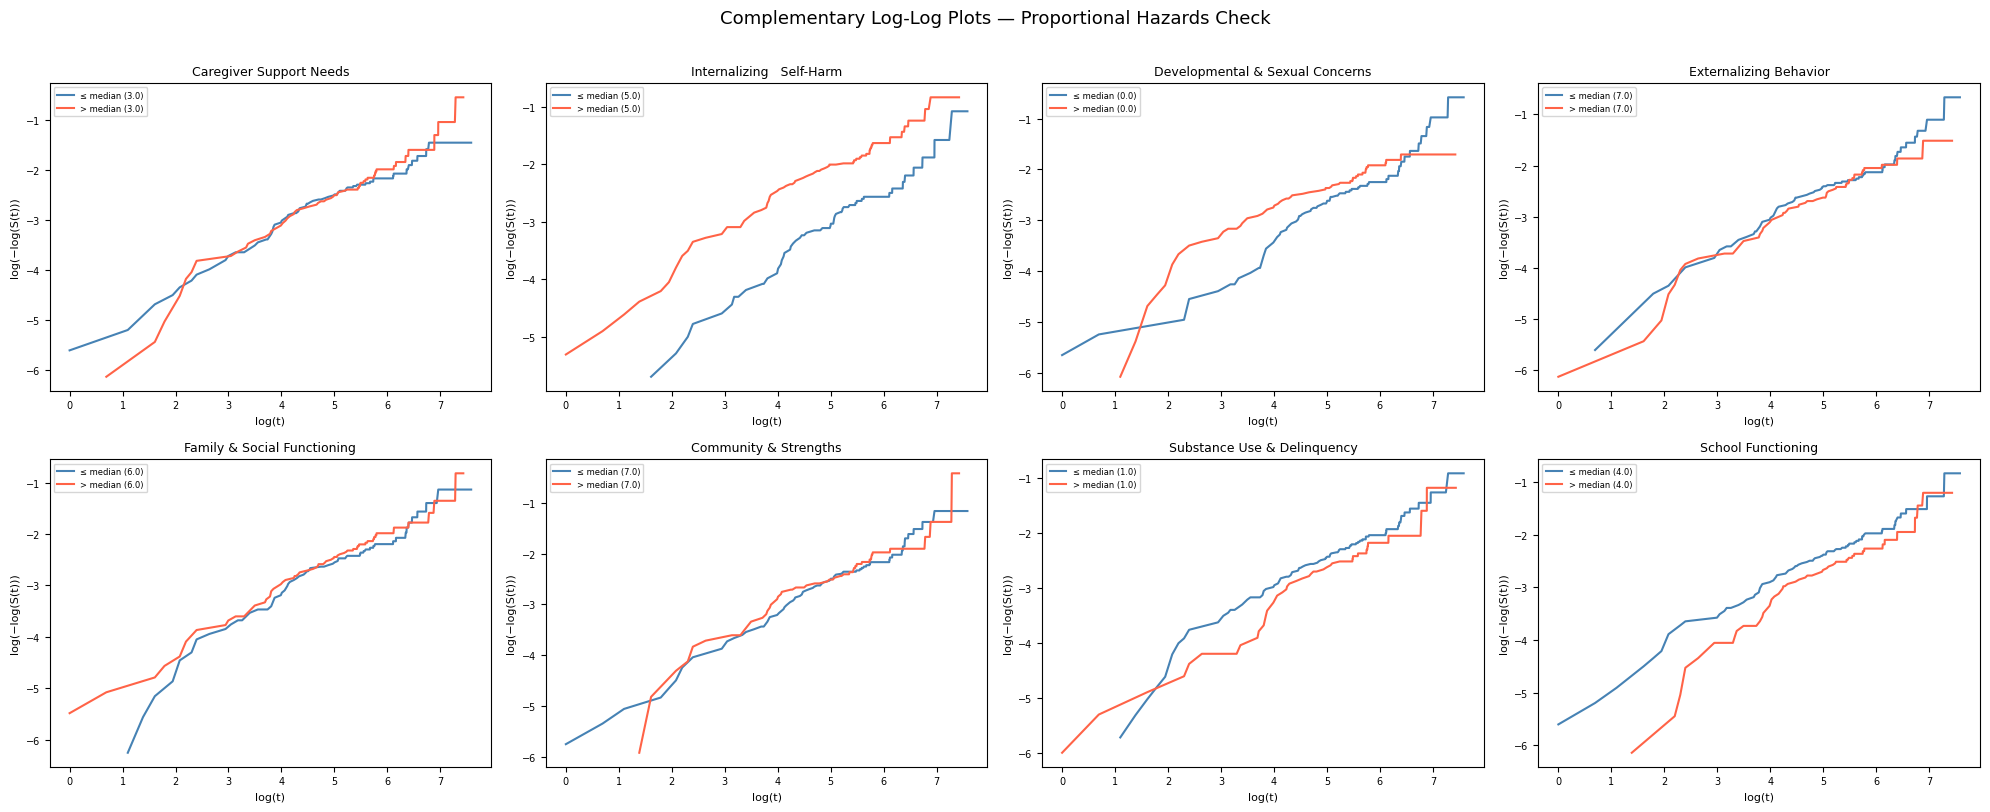

In [88]:

import warnings
from lifelines import KaplanMeierFitter

def check_cox_assumptions(cph, cox_df, covariates=None):
    """
    Complementary log-log (CLL) plots for proportional hazards assumption check.

    For each covariate, the data is split at the median (or on its two binary values)
    and the log(−log(S(t))) vs log(t) is plotted for each stratum. Under the
    proportional hazards assumption, the two lines should run roughly parallel.
    Crossing or diverging lines indicate a possible PH violation.
    """
    if covariates is None:
        covariates = [c for c in cox_df.columns
                      if c not in {cph.duration_col, cph.event_col}]

    dur_col = cph.duration_col
    event_col = cph.event_col

    n_cols = 4
    n_rows = int(np.ceil(len(covariates) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    print(f"Concordance Index: {cph.concordance_index_:.4f}\n")

    for i, covar in enumerate(covariates):
        ax = axes[i]
        col = cox_df[covar].dropna()

        unique_vals = sorted(col.unique())
        if len(unique_vals) == 2:
            groups = [(cox_df[covar] == unique_vals[0], f"{covar}={unique_vals[0]}"),
                      (cox_df[covar] == unique_vals[1], f"{covar}={unique_vals[1]}")]
        else:
            median_val = col.median()
            groups = [(cox_df[covar] <= median_val, f"≤ median ({median_val:.1f})"),
                      (cox_df[covar] > median_val,  f"> median ({median_val:.1f})")]

        for (mask, label), color in zip(groups, ['steelblue', 'tomato']):
            group = cox_df[mask].dropna(subset=[dur_col, event_col])
            if len(group) < 5:
                continue
            kmf = KaplanMeierFitter()
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                kmf.fit(group[dur_col], event_observed=group[event_col])

            sf = kmf.survival_function_
            t = sf.index.values
            s = sf['KM_estimate'].values
            valid = (s > 0) & (s < 1) & (t > 0)
            if valid.sum() > 1:
                ax.plot(np.log(t[valid]), np.log(-np.log(s[valid])),
                        label=label, color=color, lw=1.5)

        clean = covar.replace('alt_', '').replace('_score', '').replace('_', ' ')
        ax.set_title(clean, fontsize=9)
        ax.set_xlabel('log(t)', fontsize=8)
        ax.set_ylabel('log(−log(S(t)))', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6)

    for j in range(len(covariates), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Complementary Log-Log Plots — Proportional Hazards Check', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


check_cox_assumptions(cph, cox_table, cans)


## Drill Down: Individual Items in Top Risk Group

Top risk group: Internalizing_/_Self-Harm
Items in group: ['Sleep', 'Anxiety', 'Adjustment To Trauma', 'Depression', 'Other Self Harm (Recklessness)', 'Non-Suicidal Self Injurious Behavior', 'Suicide Risk']
Drill shape: (1006, 13),  Events: 121


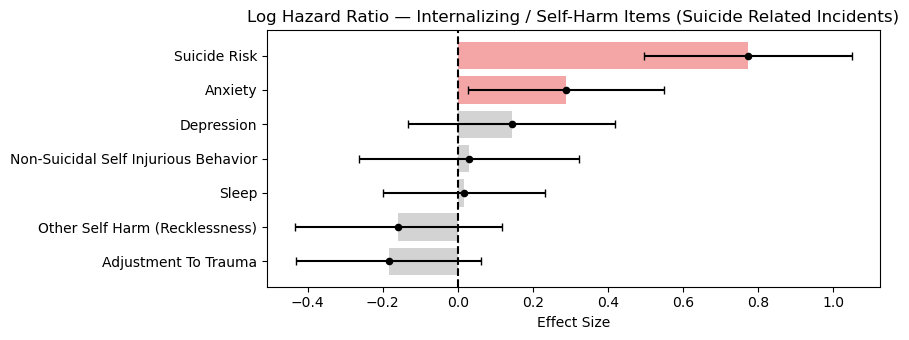


Top 3 items:
  Suicide Risk: coef=0.7739, p=4.2901e-08
  Anxiety: coef=0.2884, p=3.0196e-02
  Adjustment To Trauma: coef=-0.1843, p=1.4202e-01


In [89]:

ALT_TO_GROUP = {
    'alt_Caregiver_Support_Needs_score':         'Caregiver_Support_Needs',
    'alt_Internalizing___Self-Harm_score':        'Internalizing_/_Self-Harm',
    'alt_Developmental_&_Sexual_Concerns_score':  'Developmental_&_Sexual_Concerns',
    'alt_Externalizing_Behavior_score':           'Externalizing_Behavior',
    'alt_Family_&_Social_Functioning_score':      'Family_&_Social_Functioning',
    'alt_Community_&_Strengths_score':            'Community_&_Strengths',
    'alt_Substance_Use_&_Delinquency_score':      'Substance_Use_&_Delinquency',
    'alt_School_Functioning_score':               'School_Functioning',
}

# 1. Identify top risk group (highest coef among alt_ covariates, exclude demographics)
top_alt_col = cph.summary.loc[cans, 'coef'].idxmax()
top_group = ALT_TO_GROUP[top_alt_col]
print(f"Top risk group: {top_group}")

# 2. Load category_mapping and get individual items for that group
CATEGORY_MAPPING_PATH = '/Users/daniellancet/Desktop/Spring_2026/CDSS_170/CANS_INCIDENTS_PROJECT/Novel_Data/category_mapping.csv'
category_mapping = pd.read_csv(CATEGORY_MAPPING_PATH)
group_items = category_mapping.loc[category_mapping['group'] == top_group, 'variable'].tolist()
group_items = [v for v in group_items if v in just_first_assessement.columns]
print(f"Items in group: {group_items}")

# 3. Build drill_df and fit individual-item Cox model (same simple approach as main model)
demo_cols = ['AgeWhenAssessed', 'Black', 'Latino', 'Other']
dur = 'T_' + INCIDENT_TYPE
event_col = 'status_' + INCIDENT_TYPE
drill_df = just_first_assessement[[dur, event_col] + group_items + demo_cols].dropna()
print(f"Drill shape: {drill_df.shape},  Events: {int(drill_df[event_col].sum())}")

cph_drill = CoxPHFitter()
cph_drill.fit(drill_df, duration_col=dur, event_col=event_col)

# 4. Plot item-level coefficients (exclude demographics)
plot_cox_coefs(cph_drill, exclude_vars=demo_cols,
               title=f"Log Hazard Ratio — {top_group.replace('_', ' ')} Items ({INCIDENT_TYPE})")

# 5. Identify top 3 items by absolute coefficient
top_items = (
    cph_drill.summary.loc[group_items, 'coef']
    .abs().nlargest(3).index.tolist()
)
print(f"\nTop 3 items:")
for item in top_items:
    print(f"  {item}: coef={cph_drill.summary.loc[item, 'coef']:.4f}, "
          f"p={cph_drill.summary.loc[item, 'p']:.4e}")


## Partial Effects: Survival Curves for Top 3 CANS Items

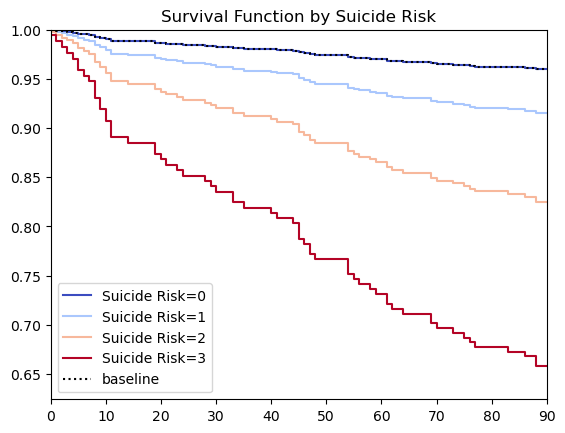

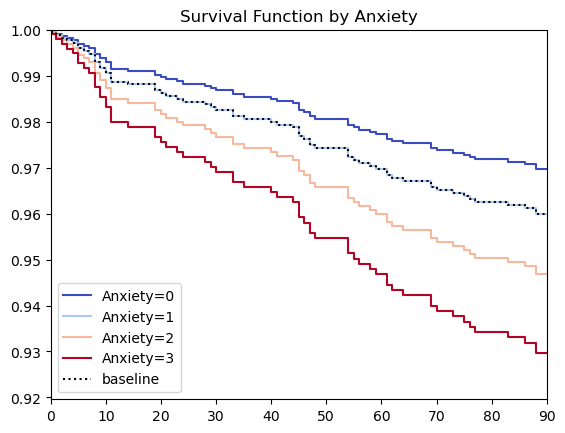

In [90]:
plot_survival_curves(cph_drill, top_items, values 
                     = [0, 1, 2, 3])


## 90-Day Incident Probability by Top 3 CANS Item Scores

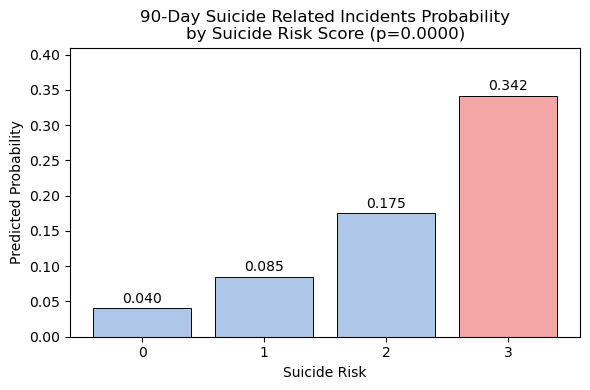

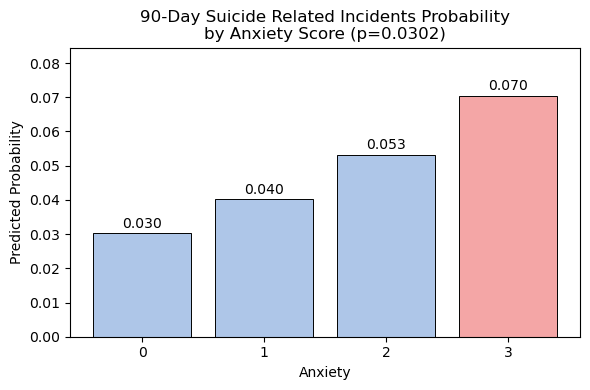

Skipping Adjustment To Trauma (p=0.1420, not significant)


In [91]:

dur = 'T_' + INCIDENT_TYPE
event_col = 'status_' + INCIDENT_TYPE
baseline_90 = drill_df.drop(columns=[dur, event_col]).median().to_frame().T

score_values = [0, 1, 2, 3]

for item in top_items:
    p_val = cph_drill.summary.loc[item, 'p']
    if p_val >= 0.05:
        print(f"Skipping {item} (p={p_val:.4f}, not significant)")
        continue

    probs_90 = []
    for v in score_values:
        row = baseline_90.copy()
        row[item] = v
        s = cph_drill.predict_survival_function(row, times=[90]).values[0][0]
        probs_90.append(1 - s)

    fig, ax = plt.subplots(figsize=(6, 4))
    bar_colors = ['#f4a6a6' if p == max(probs_90) else '#aec6e8' for p in probs_90]
    bars = ax.bar([str(v) for v in score_values], probs_90,
                  color=bar_colors, edgecolor='black', linewidth=0.7)

    for bar, prob in zip(bars, probs_90):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(probs_90) * 0.01,
            f'{prob:.3f}',
            ha='center', va='bottom', fontsize=10
        )

    ax.set_xlabel(item)
    ax.set_ylabel('Predicted Probability')
    ax.set_title(f'90-Day {INCIDENT_TYPE} Probability\nby {item} Score (p={p_val:.4f})')
    ax.set_ylim(0, max(probs_90) * 1.2)
    plt.tight_layout()
    plt.show()


## Risk Profiles

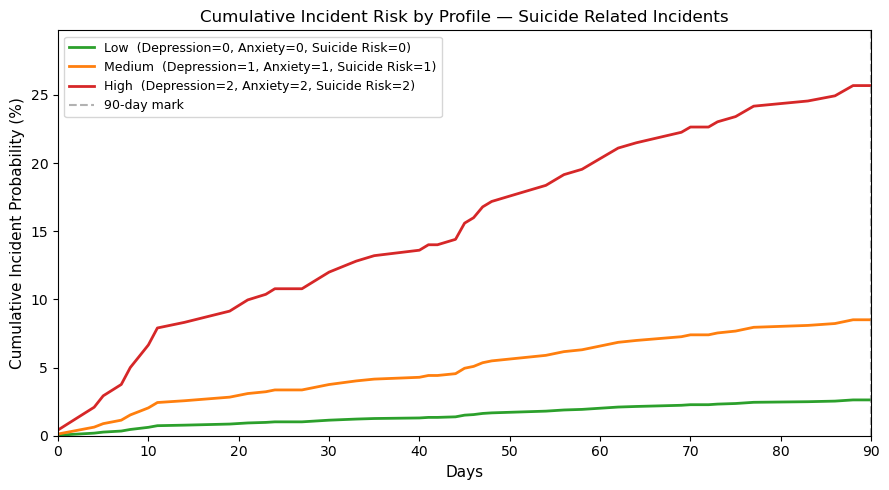

In [92]:

def _resolve_profile(feature_cols, scores):
    resolved = {}
    unmatched = []
    for key, val in scores.items():
        candidates = [c for c in feature_cols if key.lower() in c.lower()]
        if not candidates:
            unmatched.append(key)
            continue
        exact = [c for c in candidates if c.lower() == key.lower()]
        col = exact[0] if exact else candidates[0]
        if not exact and len(candidates) > 1:
            print(f"Ambiguous match for '{key}': {candidates}. Using '{col}'.")
        resolved[col] = float(val)
    return resolved, unmatched


dur = 'T_' + INCIDENT_TYPE
event_col = 'status_' + INCIDENT_TYPE
_TIER_COLORS = {'low': '#2ca02c', 'medium': '#ff7f0e', 'high': '#d62728'}
_FALLBACK_COLORS = ['steelblue', 'purple', 'brown', 'teal', 'olive']

feature_cols_profile = [c for c in drill_df.columns if c not in {dur, event_col}]
t_max = int(drill_df[dur].max())
times = list(range(0, t_max + 1))
time_horizon = 90

baseline_profile = drill_df[feature_cols_profile].median().to_frame().T.reset_index(drop=True)

profiles = {
    'Low':    {'Depression': 0, 'Anxiety': 0, 'Suicide Risk': 0},
    'Medium': {'Depression': 1, 'Anxiety': 1, 'Suicide Risk': 1},
    'High':   {'Depression': 2, 'Anxiety': 2, 'Suicide Risk': 2},
}

fig, ax = plt.subplots(figsize=(9, 5))
all_max_risks = []
fallback_idx = 0

for tier_label, scores in profiles.items():
    color = _TIER_COLORS.get(tier_label.lower())
    if color is None:
        color = _FALLBACK_COLORS[fallback_idx % len(_FALLBACK_COLORS)]
        fallback_idx += 1

    resolved, unmatched = _resolve_profile(feature_cols_profile, scores)
    if unmatched:
        print(f"[{tier_label}] Warning: no column match found for: {unmatched}")

    profile = baseline_profile.copy()
    for col, val in resolved.items():
        profile[col] = val

    x_max = min(time_horizon, t_max)
    sf = cph_drill.predict_survival_function(profile, times=times)
    cum_risk_pct = (1 - sf.values.flatten()) * 100
    visible_risk = cum_risk_pct[:x_max + 1]
    all_max_risks.append(max(visible_risk))

    score_label = ', '.join(f'{k}={v}' for k, v in scores.items())
    ax.plot(times, cum_risk_pct, color=color, lw=2,
            label=f'{tier_label}  ({score_label})')

y_max = max(all_max_risks) if all_max_risks else 10
ax.set_title(f'Cumulative Incident Risk by Profile — {INCIDENT_TYPE}', fontsize=12)
ax.set_xlabel('Days', fontsize=11)
ax.set_ylabel('Cumulative Incident Probability (%)', fontsize=11)
x_max = min(time_horizon, t_max)
ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max * 1.15 + 0.2)
ax.axvline(time_horizon, color='grey', linestyle='--', alpha=0.6, label=f'{time_horizon}-day mark')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()
